<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Pie Charts**


Estimated time needed: **30** minutes


- In this lab, you will focus on visualizing data.

- The provided dataset will be loaded into pandas for analysis.

- Various pie charts will be created to:
   - Analyze developer preferences.
  
   - Identify technology usage trends.
    
- The lab aims to provide insights into key variables using visual representations.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 155.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 191.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 147.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 146.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-09-29 11:16:00--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  3.11MB/s    in 44s     

2026-09-29 11:16:45 (3.43 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Composition with Pie Charts


##### 1.1 Create a Pie Chart of the Top 5 Databases Respondents Want to Work With


In the survey data, the `DatabaseWantToWorkWith` column lists the databases that respondents wish to work with. Let’s visualize the top 5 most-desired databases in a pie chart.



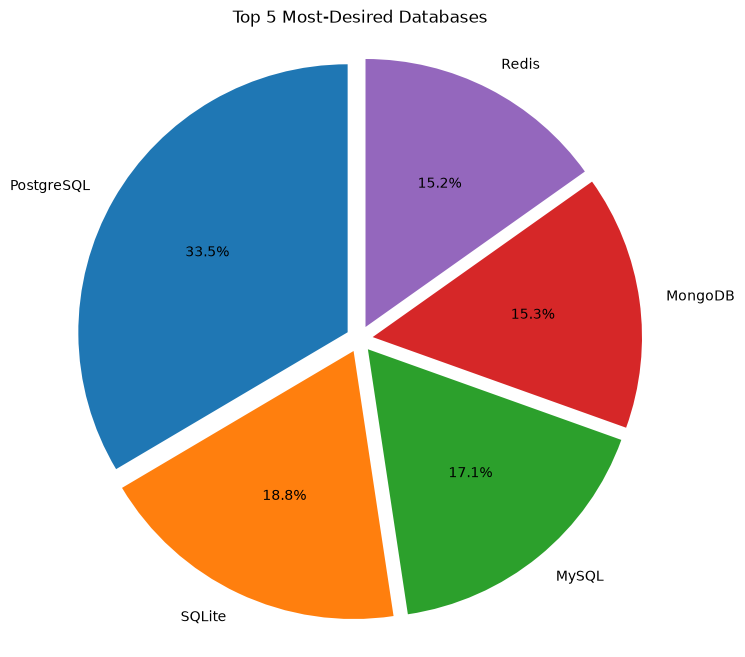

In [3]:
# Select the column and remove missing values
db_df = df[["DatabaseWantToWorkWith"]].dropna()

# Split multiple databases into separate rows
db_df = db_df.assign(
    Database=db_df["DatabaseWantToWorkWith"].str.split(";")
).explode("Database")

# Remove extra spaces
db_df["Database"] = db_df["Database"].str.strip()

# Get the top 5 most-desired databases
top5_databases = db_df["Database"].value_counts().head(5)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    top5_databases,
    labels=top5_databases.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05] * 5
)

plt.title("Top 5 Most-Desired Databases")
plt.axis("equal")

plt.show()

The `DevType` column lists the developer types for respondents. We’ll examine the distribution by showing the top 5 developer roles in a pie chart.



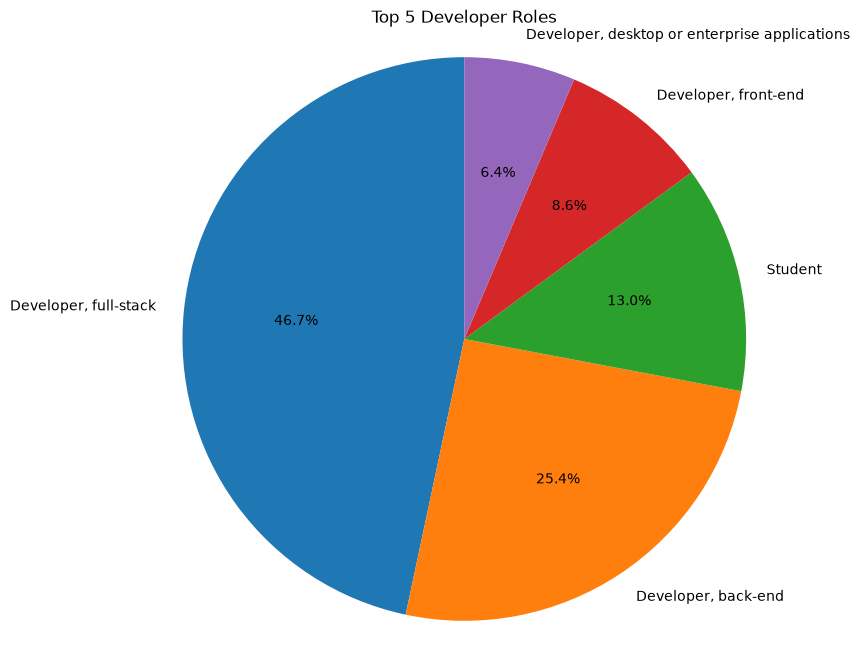

In [4]:
# Select DevType column and remove missing values
dev_df = df[["DevType"]].dropna()

# Split respondents with multiple developer roles
dev_df = dev_df.assign(
    Role=dev_df["DevType"].str.split(";")
).explode("Role")

# Remove extra spaces
dev_df["Role"] = dev_df["Role"].str.strip()

# Get the top 5 developer roles
top5_roles = dev_df["Role"].value_counts().head(5)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    top5_roles,
    labels=top5_roles.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Developer Roles")
plt.axis("equal")

plt.show()

##### 1.3 Create a pie chart for the operating systems used by respondents for professional use


The `OpSysProfessional` use column shows the operating systems developers use professionally. Let’s visualize the distribution of the top operating systems in a pie chart.



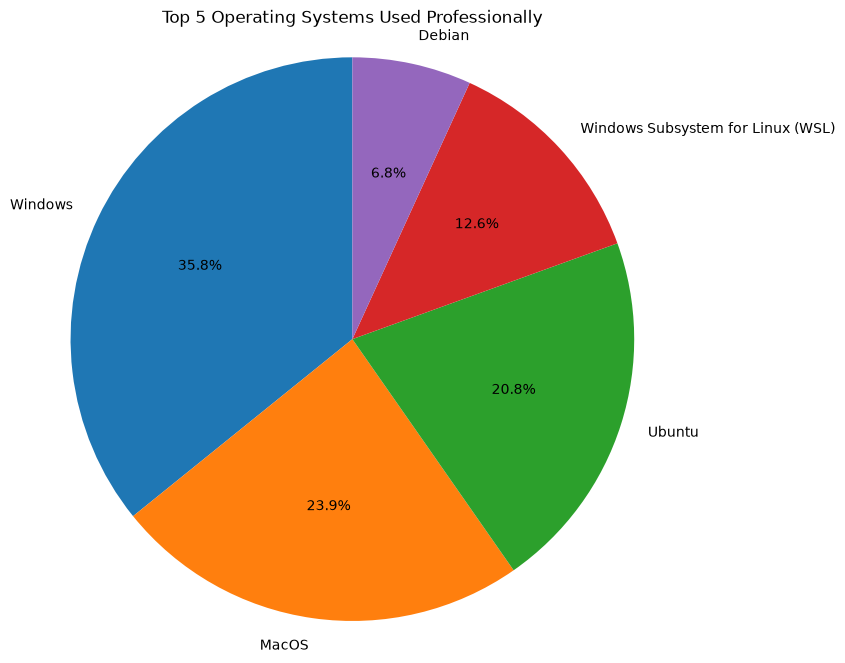

In [8]:
# Select the column and remove missing values
os_df = df[["OpSysProfessional use"]].dropna()

# Split multiple operating systems into separate rows
os_df = os_df.assign(
    OperatingSystem=os_df["OpSysProfessional use"].str.split(";")
).explode("OperatingSystem")

# Remove extra spaces
os_df["OperatingSystem"] = os_df["OperatingSystem"].str.strip()

# Get frequency counts
os_counts = os_df["OperatingSystem"].value_counts()

# Keep the top 5 operating systems
top_os = os_counts.head(5)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    top_os,
    labels=top_os.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Operating Systems Used Professionally")
plt.axis("equal") # Makes the pie chart circular
plt.show()

### Task 2: Additional Visualizations and Comparisons


##### 2.1 Pie Chart for Top 5 Programming Languages Respondents Have Worked With


The `LanguageHaveWorkedWith` column contains the programming languages that respondents have experience with. We’ll plot a pie chart to display the composition of the top 5 languages.



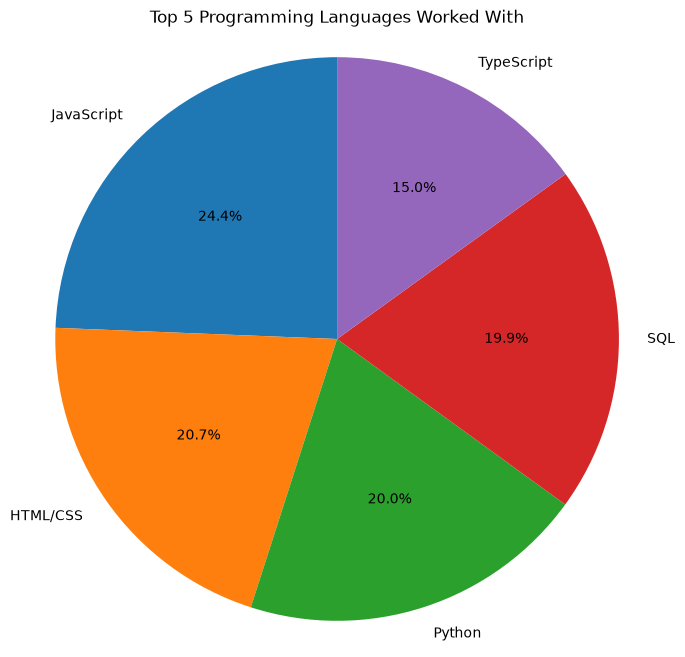

In [9]:
# Select the column and remove missing values
lang_df = df[["LanguageHaveWorkedWith"]].dropna()

# Split multiple languages into separate rows
lang_df = lang_df.assign(
    Language=lang_df["LanguageHaveWorkedWith"].str.split(";")
).explode("Language")

# Remove extra spaces
lang_df["Language"] = lang_df["Language"].str.strip()

# Get the top 5 languages
top5_languages = lang_df["Language"].value_counts().head(5)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    top5_languages,
    labels=top5_languages.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Programming Languages Worked With")
plt.axis("equal")

plt.show()

##### 2.2 Pie Chart for Top Collaboration Tools used in Professional Use


Using the `NEWCollabToolsHaveWorkedWith` column, we’ll identify and visualize the top collaboration tools respondents use in their professional work.



Tool
Visual Studio Code    42751
Visual Studio         17021
IntelliJ IDEA         15555
Notepad++             13874
Vim                   12523
Name: count, dtype: int64

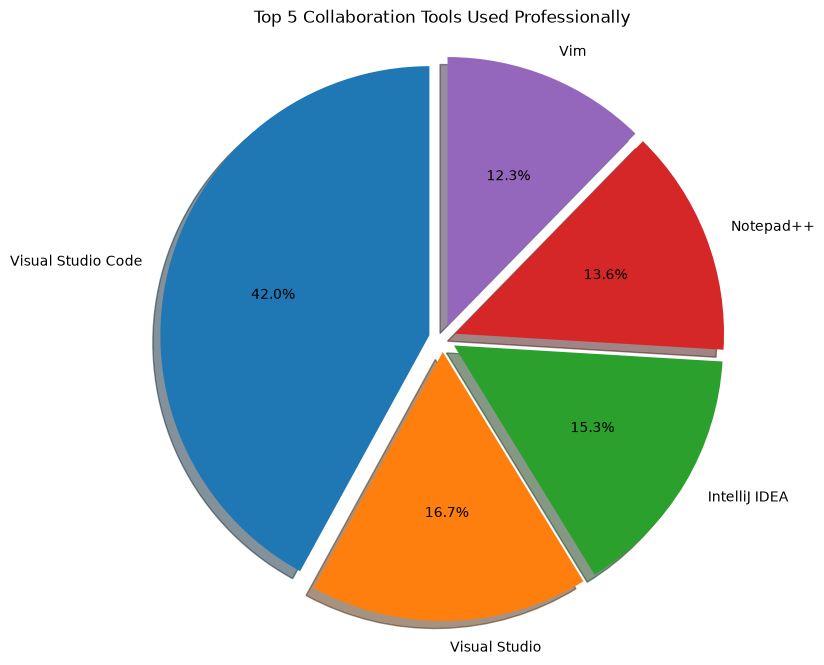

In [10]:
# Select the collaboration tools column
tools_df = df[["NEWCollabToolsHaveWorkedWith"]].dropna()

# Split multiple tools into individual rows
tools_df = tools_df.assign(
    Tool=tools_df["NEWCollabToolsHaveWorkedWith"].str.split(";")
).explode("Tool")

# Remove leading/trailing spaces
tools_df["Tool"] = tools_df["Tool"].str.strip()

# Count tool frequencies
tool_counts = tools_df["Tool"].value_counts()

# Select the top 5 collaboration tools
top_5_tools = tool_counts.head(5)

# Display counts
print(top_5_tools)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
top_5_tools.values,
labels=top_5_tools.index,
autopct="%1.1f%%",
startangle=90,
explode=[0.05] * len(top_5_tools),
shadow=True
)

plt.title("Top 5 Collaboration Tools Used Professionally")
plt.axis("equal")

plt.show()

### Task 3: Analyzing and Interpreting Composition


In this task, you will create additional pie charts to analyze specific aspects of the survey data. Use `pandas` and `matplotlib` to complete each task and interpret the findings.



##### 3.1 Pie Chart of `Respondents` Most Admired Programming Languages


The `LanguageAdmired` column lists the programming languages respondents admire most. Create a pie chart to visualize the top 5 admired languages.



Language
JavaScript    21869
Python        20774
SQL           20692
HTML/CSS      19851
TypeScript    16079
Name: count, dtype: int64

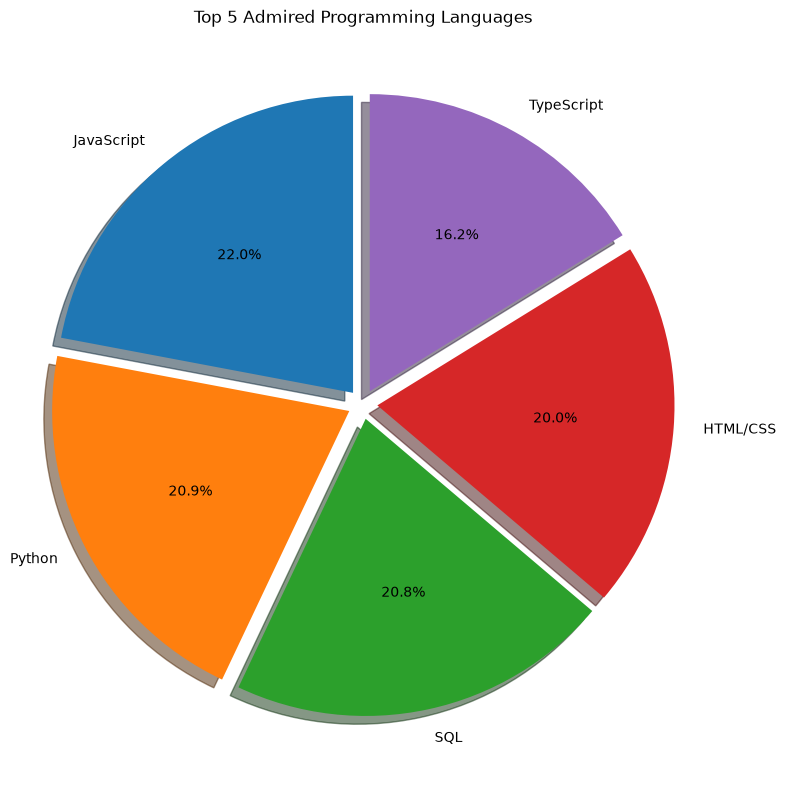

In [11]:
# Select the LanguageAdmired column and remove missing values
admired_df = df[["LanguageAdmired"]].dropna()

# Split multiple languages into separate rows
admired_df = admired_df.assign(
    Language=admired_df["LanguageAdmired"].str.split(";")
).explode("Language")

# Remove leading/trailing spaces
admired_df["Language"] = admired_df["Language"].str.strip()

# Count frequency of admired languages
language_counts = admired_df["Language"].value_counts()

# Select the top 5 admired languages
top_5_languages = language_counts.head(5)

# Display counts
print(top_5_languages)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    top_5_languages.values,
    labels=top_5_languages.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05] * len(top_5_languages),
    shadow=True
)

plt.title("Top 5 Admired Programming Languages")
plt.axis("equal") # Ensures the pie chart is circular

plt.tight_layout()
plt.show()

##### 3.2 Pie Chart of Tools Used for AI Development


Using the `AIToolCurrently` Using column, create a pie chart to visualize the top 5 tools developers are currently using for AI development.



Tool
Writing code                            29486
Search for answers                      24295
Debugging and getting help              20404
Documenting code                        14439
Generating content or synthetic data    12538
Name: count, dtype: int64

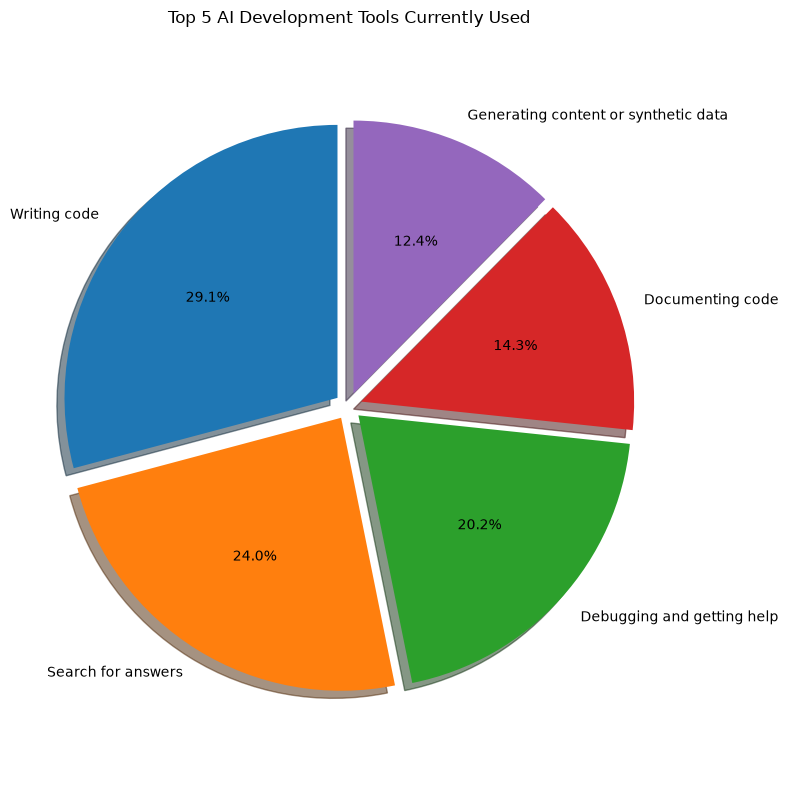

In [13]:
# Select the AI tools column and remove missing values
ai_df = df[["AIToolCurrently Using"]].dropna()

# Split multiple tools into separate rows
ai_df = ai_df.assign(
    Tool=ai_df["AIToolCurrently Using"].str.split(";")
).explode("Tool")

# Remove leading/trailing spaces
ai_df["Tool"] = ai_df["Tool"].str.strip()

# Count frequency of tool usage
tool_counts = ai_df["Tool"].value_counts()

# Select the top 5 AI tools currently used
top_5_tools = tool_counts.head(5)

# Display counts
print(top_5_tools)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    top_5_tools.values,
    labels=top_5_tools.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05] * len(top_5_tools),
    shadow=True
)

plt.title("Top 5 AI Development Tools Currently Used")
plt.axis("equal")

plt.tight_layout()
plt.show()

##### 3.3 Pie Chart for Preferred Web Frameworks


The `WebframeWantToWorkWith` column includes web frameworks that respondents are interested in working with. Visualize the top 5 frameworks in a pie chart.



Framework
React           15404
Node.js         14735
Next.js          8507
Vue.js           7604
ASP.NET CORE     6905
Name: count, dtype: int64

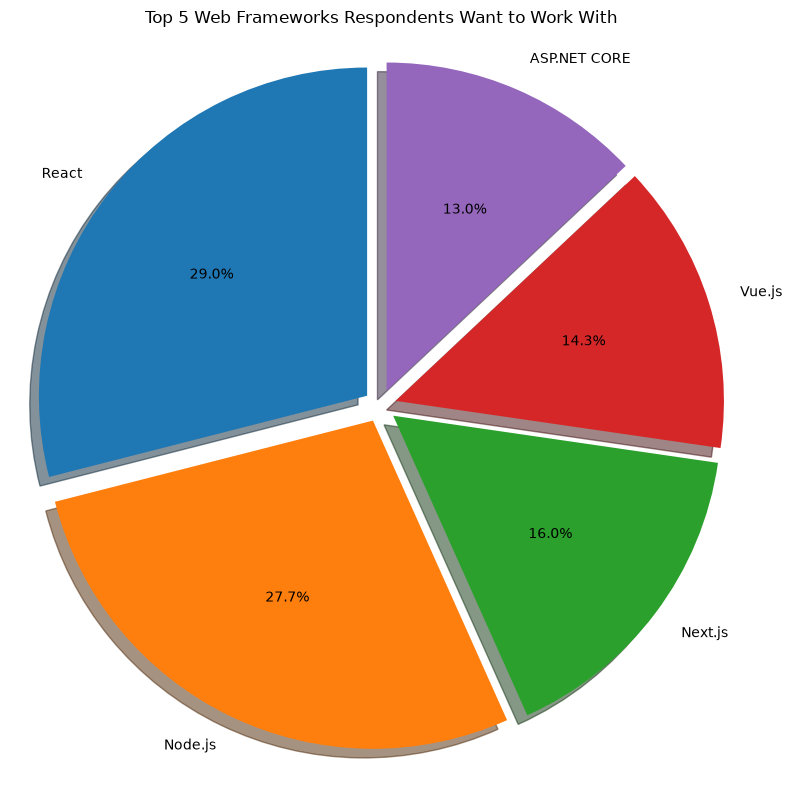

In [14]:
# Select the web frameworks column and remove missing values
framework_df = df[["WebframeWantToWorkWith"]].dropna()

# Split multiple frameworks into separate rows
framework_df = framework_df.assign(
    Framework=framework_df["WebframeWantToWorkWith"].str.split(";")
).explode("Framework")

# Remove leading/trailing spaces
framework_df["Framework"] = framework_df["Framework"].str.strip()

# Count frequency of framework interest
framework_counts = framework_df["Framework"].value_counts()

# Select the top 5 desired frameworks
top_5_frameworks = framework_counts.head(5)

# Display counts
print(top_5_frameworks)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    top_5_frameworks.values,
    labels=top_5_frameworks.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05] * len(top_5_frameworks),
    shadow=True
)

plt.title("Top 5 Web Frameworks Respondents Want to Work With")
plt.axis("equal")

plt.tight_layout()
plt.show()

##### 3.4 Pie Chart for Most Desired Embedded Technologies


Using the `EmbeddedWantToWorkWith` column, create a pie chart to show the top 5 most desired embedded technologies that respondents wish to work with.



Technology
Rasberry Pi    9792
Arduino        6482
GNU GCC        5870
CMake          4693
Cargo          4567
Name: count, dtype: int64

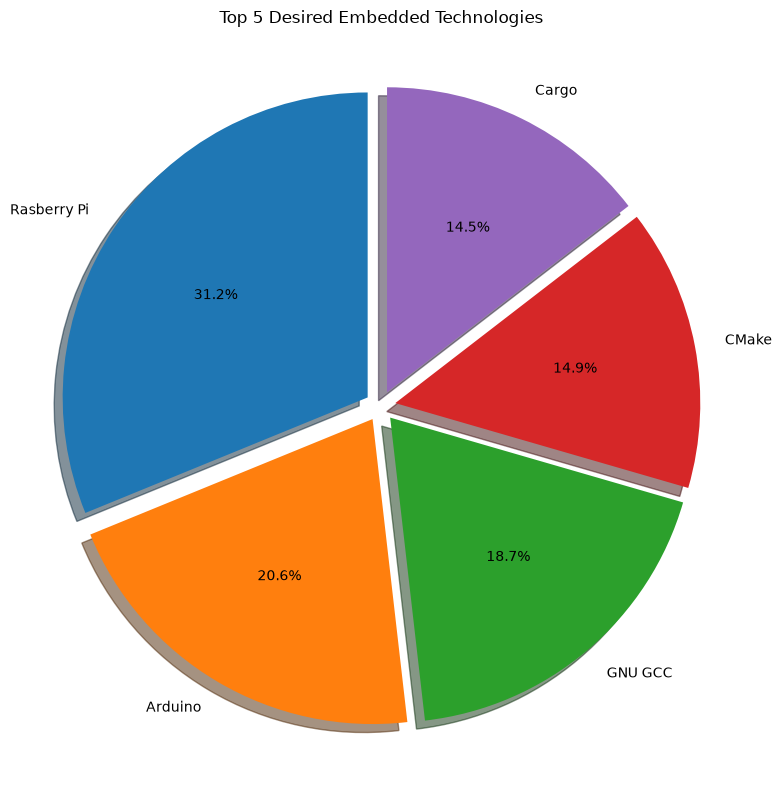

In [15]:
# Select the embedded technologies column and remove missing values
embedded_df = df[["EmbeddedWantToWorkWith"]].dropna()

# Split multiple technologies into separate rows
embedded_df = embedded_df.assign(
    Technology=embedded_df["EmbeddedWantToWorkWith"].str.split(";")
).explode("Technology")

# Remove leading/trailing spaces
embedded_df["Technology"] = embedded_df["Technology"].str.strip()

# Count frequency of desired technologies
tech_counts = embedded_df["Technology"].value_counts()

# Select the top 5 most desired embedded technologies
top_5_tech = tech_counts.head(5)

# Display counts
print(top_5_tech)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    top_5_tech.values,
    labels=top_5_tech.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05] * len(top_5_tech),
    shadow=True
)

plt.title("Top 5 Desired Embedded Technologies")
plt.axis("equal")

plt.tight_layout()
plt.show()

### Summary


After completing this lab, you will be able to:
- Create pie charts to visualize developer preferences across databases, programming languages, AI tools, and cloud platforms.
- Identify trends in technology usage, role distribution, and tool adoption through pie charts.
- Analyze and compare data composition across various categories to gain insights into developer preferences.




## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
